## Notebook summary

| Item | Details |
| --- | --- |
| Purpose | Knee Joint Detection using YOLOv8 CLI |
| Model / workflow | YOLOv8 |
| Input | not reported |
| Loss | not reported |
| Training / pipeline | YOLO detection/ROI workflow |
| Result | url: https://app.roboflow.com/nguyens-workspace-tm7at/knee-joint-84k23/dataset; [34m[1mengine/trainer: [0magnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, chann...; Epoch... |


# Knee Joint Detection using YOLOv8 CLI

This notebook trains a YOLOv8 model for Knee Joint detection using the YOLO CLI.
It is configured to run in **Google Colab** using the dataset files stored in Google Drive.

**Dataset:** `Knee Xray Yolo.yolov8.zip` (~1500 images)
**Checkpoints:** Saved into the Google Drive `Models/yolov8_checkpoint` directory.

## 0. Import libraries & Setup Device
Import library, load device, connect to Google Drive.

In [ ]:
import os
import shutil
import yaml
import torch
import cv2
import matplotlib.pyplot as plt

# Try mounting drive (if on Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")
except ImportError:
    print("Not running in Google Colab. Skipping Drive mount.")

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# Install ultralytics if needed
try:
    from ultralytics import YOLO
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "ultralytics"])
    from ultralytics import YOLO

Mounted at /content/drive
Google Drive mounted successfully.
Using device: cuda
GPU Name: Tesla T4
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 1. Prepare Dataset & Configuration
Unzip dataset from Google Drive and dynamically locate the extracted dataset files.

In [ ]:
import subprocess
import os

# 1. Unzip dataset from Drive if running on Google Colab
dataset_zip = "/content/drive/MyDrive/Datasets/Knee Joint.yolov8.zip"
search_root = "/content/Datasets"

if os.path.exists(dataset_zip):
    print("Unzipping dataset from Google Drive...")
    subprocess.run(["unzip", "-q", dataset_zip, "-d", search_root])
else:
    print("Zip file not found at default Drive path. Assuming local dataset path.")

# 2. Locate data.yaml dynamically within search_root
# This handles cases where Roboflow unzips as flat files or nested in a subdirectory.
yaml_path = None
dataset_root = None

for root, dirs, files in os.walk(search_root):
    if "data.yaml" in files:
        yaml_path = os.path.join(root, "data.yaml")
        dataset_root = root
        break

if yaml_path is None:
    raise FileNotFoundError(f"Could not locate 'data.yaml' anywhere inside {search_root}")

# =========================================================================
# CONFIGURATION & PARAMETERS (Unified Input Config)
# =========================================================================
class TrainingConfig:
    # Model Selection
    model_name = "yolov8n.pt"         # Use YOLOv8 Nano for fast inference and fine-tuning
    task = "detect"
    
    # Dataset & Paths (Resolved dynamically)
    dataset_root = dataset_root
    yaml_path = yaml_path
    checkpoint_dir = "/content/drive/MyDrive/Models"
    
    # Training Parameters
    img_size = 640                    # Standard YOLOv8 image size
    batch_size = 16
    epochs = 100                      # Default best for training 1500 images
    patience = 10                     # Early stopping patience
    seed = 42

print("=================================================================")
print(" ACTIVE YOLOv8 TRAINING CONFIGURATION LOG")
print("=================================================================")
for key, value in TrainingConfig.__dict__.items():
    if not key.startswith("__"):
        print(f"{key:<25} : {value}")
print("=================================================================")

Unzipping dataset from Google Drive...
 ACTIVE YOLOv8 TRAINING CONFIGURATION LOG
model_name                : yolov8n.pt
task                      : detect
dataset_root              : /content/Datasets
yaml_path                 : /content/Datasets/data.yaml
checkpoint_dir            : /content/drive/MyDrive/Models
img_size                  : 640
batch_size                : 16
epochs                    : 100
patience                  : 10
seed                      : 42


## 2. Generate Training YAML
Configure dataset absolute paths dynamically in the extracted `data.yaml` to prevent directory resolution issues during training.

In [ ]:
import yaml

# Load original data.yaml file and overwrite relative paths with clean absolute paths
if os.path.exists(TrainingConfig.yaml_path):
    with open(TrainingConfig.yaml_path, 'r') as f:
        data_config = yaml.safe_load(f)

    # Set absolute paths to ensure YOLO finds the dataset splits correctly
    data_config['path'] = os.path.abspath(TrainingConfig.dataset_root)
    data_config['train'] = 'train/images'
    data_config['val'] = 'valid/images'
    data_config['test'] = 'test/images'

    with open(TrainingConfig.yaml_path, 'w') as f:
        yaml.dump(data_config, f, default_flow_style=False)

    print(f"Successfully updated data.yaml in-place at: {TrainingConfig.yaml_path}")
    with open(TrainingConfig.yaml_path, 'r') as f:
        print(f.read())
else:
    print(f"Error: {TrainingConfig.yaml_path} does not exist. Cannot generate training config.")

Successfully updated data.yaml in-place at: /content/Datasets/data.yaml
names:
- joint
nc: 1
path: /content/Datasets
roboflow:
  license: Private
  project: knee-joint-84k23
  url: https://app.roboflow.com/nguyens-workspace-tm7at/knee-joint-84k23/dataset
  version: dataset
  workspace: nguyens-workspace-tm7at
test: test/images
train: train/images
val: valid/images



## 3. Train YOLOv8 Model using YOLO CLI

We use the YOLO Command Line Interface (`yolo detect train`) to train the model.

Parameters configured:
- `model`: `yolov8n.pt` (Pre-trained Nano weights)
- `epochs`: `100` (Convergence target)
- `imgsz`: `640` (Standard input scale)
- `batch`: `16`
- `project`: `/content/drive/MyDrive/Models`
- `name`: `yolov8_checkpoint` (Saves weights to `Models/yolov8_checkpoint` folder)
- `exist_ok`: `True` (Overwrites the checkpoint folder directory)
- `hsv_h=0.0, hsv_s=0.0`: Disabled color augmentations since X-ray images are purely grayscale.

In [ ]:
# Store config attributes in local variables so IPython expands them properly in shell commands
model_name = TrainingConfig.model_name
yaml_path = TrainingConfig.yaml_path
epochs = TrainingConfig.epochs
img_size = TrainingConfig.img_size
batch_size = TrainingConfig.batch_size
project_dir = TrainingConfig.checkpoint_dir

# Start fine-tuning using YOLO CLI
!yolo detect train model={model_name} data="{yaml_path}" epochs={epochs} imgsz={img_size} batch={batch_size} device=0 project="{project_dir}" name="yolov8_checkpoint" exist_ok=True hsv_h=0.0 hsv_s=0.0

Ultralytics 8.4.106 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Datasets/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_checkpoint, nbs=64, nms=Fals

## 4. Evaluate Model Performance
Validate the best checkpoint on the validation set.

In [ ]:
best_model_weights = os.path.join(TrainingConfig.checkpoint_dir, "yolov8_checkpoint", "weights", "best.pt")
yaml_path = TrainingConfig.yaml_path
img_size = TrainingConfig.img_size

if os.path.exists(best_model_weights):
    print(f"Found best model weights at: {best_model_weights}. Running validation...")
    !yolo detect val model="{best_model_weights}" data="{yaml_path}" imgsz={img_size} device=0
else:
    print(f"Could not find model weights at: {best_model_weights}. Please run training first.")

Found best model weights at: /content/drive/MyDrive/Models/yolov8_checkpoint/weights/best.pt. Running validation...
Ultralytics 8.4.106 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3827.7±1199.0 MB/s, size: 3507.0 KB)
val: Scanning /content/Datasets/valid/labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 58/58 11.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.3s/it 5.2s1.7ss
                   all         58        117          1      0.991      0.995      0.902
Speed: 1.4ms preprocess, 15.4ms inference, 0.0ms loss, 3.6ms postprocess per image
Results saved to /content/runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


## 5. Inference & Cropping Demonstration
Run inference on a sample image from the test set, visualize the predictions, and crop the detected Knee Joint ROI.

Running inference on: /content/Datasets/test/images/9323060_20060601_01545104_png_png.rf.7Iny1lvC1j4mZvd9cFFY.png
Ultralytics 8.4.106 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

image 1/1 /content/Datasets/test/images/9323060_20060601_01545104_png_png.rf.7Iny1lvC1j4mZvd9cFFY.png: 544x640 2 joints, 50.6ms
Speed: 4.0ms preprocess, 50.6ms inference, 18.9ms postprocess per image at shape (1, 3, 544, 640)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict
Detected 2 knee joint(s).


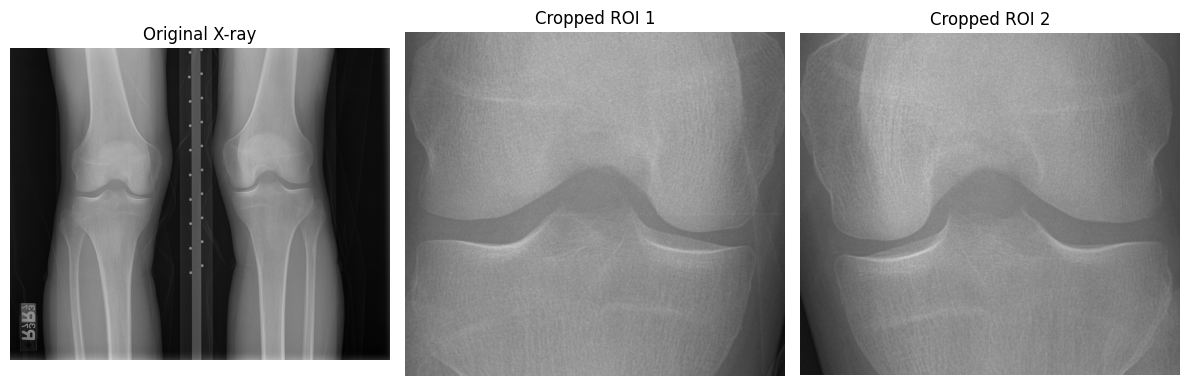

In [ ]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

test_img_dir = os.path.join(TrainingConfig.dataset_root, "test/images")

if os.path.exists(best_model_weights) and os.path.exists(test_img_dir):
    # Find sample images
    sample_images = [f for f in os.listdir(test_img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if sample_images:
        sample_path = os.path.join(test_img_dir, sample_images[0])
        print(f"Running inference on: {sample_path}")
        
        # 1. Run inference using YOLO CLI
        !yolo detect predict model="{best_model_weights}" source="{sample_path}" conf=0.25 device=0 save=True
        
        # 2. Run prediction using Python SDK to extract bounding boxes
        model = YOLO(best_model_weights)
        results = model.predict(source=sample_path, conf=0.25, device=0, verbose=False)
        
        # Display the cropped knee joints
        original_img = cv2.imread(sample_path)
        original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        
        boxes = results[0].boxes
        num_boxes = len(boxes)
        print(f"Detected {num_boxes} knee joint(s).")
        
        if num_boxes > 0:
            fig, axes = plt.subplots(1, num_boxes + 1, figsize=(12, 4))
            # Handle case where only 1 object is detected
            if num_boxes == 1:
                axes = [axes[0], axes[1]]
                
            # Plot original
            axes[0].imshow(original_img_rgb)
            axes[0].set_title("Original X-ray")
            axes[0].axis('off')
            
            # Plot cropped ROIs
            for idx, box in enumerate(boxes):
                x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
                cropped_knee = original_img_rgb[y1:y2, x1:x2]
                axes[idx+1].imshow(cropped_knee)
                axes[idx+1].set_title(f"Cropped ROI {idx+1}")
                axes[idx+1].axis('off')
                
            plt.tight_layout()
            plt.show()
        else:
            plt.figure(figsize=(6, 6))
            plt.imshow(original_img_rgb)
            plt.title("No Knee Joint Detected")
            plt.axis('off')
            plt.show()
    else:
        print("No images found in test split directory.")
else:
    print("Required weights or test directory are missing.")

## 6. Release Colab Runtime
Run this cell last to release the Colab machine after all work is complete.

In [ ]:
# Release the Colab runtime without deleting saved files in Google Drive.
from google.colab import runtime
runtime.unassign()